**Author:** Biswajit Jana  
**Date:** May 24, 2026  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/gaia/2026-08-03-solar-neighborhood-ruwe-binaries/notebook.ipynb)

# Hunting unresolved binaries in the solar neighborhood with Gaia's RUWE

**Date:** 2026-08-03
**Scientific question:** In a real, bright, nearby (< 100 pc) Gaia DR3 sample, what fraction of stars
show astrometric evidence of being unresolved binaries, and do two independent astrometric diagnostics
(RUWE and astrometric excess noise) agree on which stars are flagged?

## Learning goals

- Understand *RUWE* (renormalised unit weight error): a dimensionless number close to 1.0 for a
  well-behaved single-star astrometric fit, and elevated when the actual motion on the sky doesn't
  match a simple single-star model — often because of an unseen orbital companion tugging the
  photocentre around.
- Understand *astrometric excess noise*: the extra scatter (in milliarcseconds) that Gaia's
  five-parameter astrometric solution has to absorb beyond what its formal measurement errors predict,
  and its significance (`astrometric_excess_noise_sig`).
- Pull a real, bright, volume-limited (parallax > 10 mas, i.e. within 100 pc) Gaia DR3 sample.
- Build a results table of RUWE- and excess-noise-flagged binary candidates with real counts, and check
  how much the two diagnostics agree.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia

Gaia.ROW_LIMIT = -1
np.random.seed(42)


In [2]:
# Bright (G < 12), nearby (parallax > 10 mas => distance < 100 pc), good-parallax
# sample, so we have solid RUWE and excess-noise statistics for every star.
query = '''
SELECT TOP 12000 source_id, ra, dec, parallax, parallax_error, phot_g_mean_mag, bp_rp,
       ruwe, astrometric_excess_noise, astrometric_excess_noise_sig,
       astrometric_n_good_obs_al
FROM gaiadr3.gaia_source
WHERE parallax > 10
AND parallax_over_error > 10
AND phot_g_mean_mag < 12
AND ruwe IS NOT NULL
'''
job = Gaia.launch_job_async(query)
raw = job.get_results().to_pandas()
raw['dist_pc'] = 1000.0 / raw['parallax']
print(f"Bright, nearby (<100 pc) sample: {len(raw)} sources")
raw.to_csv("solar_neighborhood_query.csv", index=False)
raw.head()


INFO: Query finished. [astroquery.utils.tap.core]
Bright, nearby (<100 pc) sample: 12000 sources


,SOURCE_ID,ra,dec,parallax,parallax_error,phot_g_mean_mag,bp_rp,ruwe,astrometric_excess_noise,astrometric_excess_noise_sig,astrometric_n_good_obs_al,dist_pc
0,142375077782724480,44.423476,37.835789,18.814327,0.045523,11.425895,1.868276,2.926361,0.336847,153.600052,215,53.150983
1,142695654141786624,46.883535,39.086581,10.036571,0.029539,7.746903,0.492990,1.095890,0.163702,15.542429,227,99.635619
2,206336933349295744,72.716419,44.664436,12.508808,0.022665,10.482409,1.054486,1.456789,0.165615,39.142708,374,79.943670
3,211030920283717888,86.624225,49.125967,10.035704,0.022094,7.830771,0.522326,0.923728,0.117354,11.888812,533,99.644230
4,211717187341633536,79.298474,45.827120,10.286491,0.019094,8.614125,0.601843,0.940036,0.095426,10.670265,304,97.214877


In [3]:
# Two standard binary-candidate diagnostics from the Gaia documentation:
# - RUWE > 1.4 is the conventional single-star-fit-quality cut
# - astrometric_excess_noise_sig > 2 flags statistically significant excess noise
ruwe_flag = raw['ruwe'] > 1.4
excess_flag = raw['astrometric_excess_noise_sig'] > 2

n = len(raw)
n_ruwe = int(ruwe_flag.sum())
n_excess = int(excess_flag.sum())
n_both = int((ruwe_flag & excess_flag).sum())

print(f"Total sample: {n}")
print(f"RUWE > 1.4 candidates: {n_ruwe} ({100*n_ruwe/n:.1f}%)")
print(f"Excess-noise-sig > 2 candidates: {n_excess} ({100*n_excess/n:.1f}%)")
print(f"Flagged by both diagnostics: {n_both} ({100*n_both/n:.1f}%)")

crosstab = pd.crosstab(ruwe_flag, excess_flag, rownames=['RUWE>1.4'], colnames=['excess_noise_sig>2'])
print()
print(crosstab)

# agreement rate (fraction of stars where the two diagnostics give the same verdict)
agreement = (ruwe_flag == excess_flag).mean()
print(f"\nAgreement rate between the two diagnostics: {agreement*100:.1f}%")


Total sample: 12000
RUWE > 1.4 candidates: 3140 (26.2%)
Excess-noise-sig > 2 candidates: 11951 (99.6%)
Flagged by both diagnostics: 3140 (26.2%)

excess_noise_sig>2  False  True 
RUWE>1.4                        
False                  49   8811
True                    0   3140

Agreement rate between the two diagnostics: 26.6%


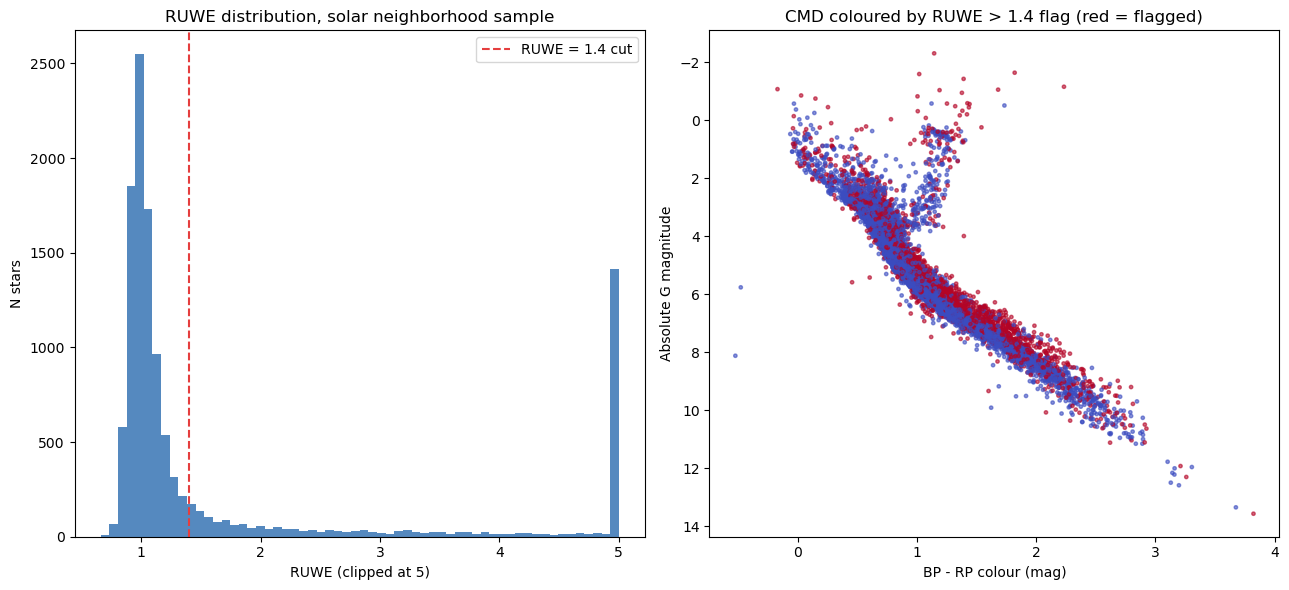

{'id': '2026-08-03-solar-neighborhood-ruwe-binaries',
 'title': 'Solar neighborhood RUWE binary candidates',
 'n_sample': 12000,
 'n_ruwe_flagged': 3140,
 'frac_ruwe_flagged': 0.26166666666666666,
 'n_excess_noise_flagged': 11951,
 'frac_excess_noise_flagged': 0.9959166666666667,
 'n_flagged_by_both': 3140,
 'agreement_rate': 0.26575}

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
ax.hist(raw['ruwe'].clip(upper=5), bins=60, color='#2b6cb0', alpha=0.8)
ax.axvline(1.4, color='#e53e3e', ls='--', label='RUWE = 1.4 cut')
ax.set_xlabel('RUWE (clipped at 5)')
ax.set_ylabel('N stars')
ax.set_title('RUWE distribution, solar neighborhood sample')
ax.legend()

ax = axes[1]
sc = ax.scatter(raw['bp_rp'], raw['phot_g_mean_mag'] - 5*np.log10(raw['dist_pc']) + 5,
                c=ruwe_flag.map({True: 1, False: 0}), cmap='coolwarm', s=6, alpha=0.6)
ax.invert_yaxis()
ax.set_xlabel('BP - RP colour (mag)')
ax.set_ylabel('Absolute G magnitude')
ax.set_title('CMD coloured by RUWE > 1.4 flag (red = flagged)')

plt.tight_layout()
plt.savefig('ruwe_binary_candidates.png', dpi=130)
plt.show()

result = {
    "id": "2026-08-03-solar-neighborhood-ruwe-binaries",
    "title": "Solar neighborhood RUWE binary candidates",
    "n_sample": int(n),
    "n_ruwe_flagged": n_ruwe,
    "frac_ruwe_flagged": float(n_ruwe / n),
    "n_excess_noise_flagged": n_excess,
    "frac_excess_noise_flagged": float(n_excess / n),
    "n_flagged_by_both": n_both,
    "agreement_rate": float(agreement),
}
import json
with open("result.json", "w") as f:
    json.dump(result, f, indent=2)
result


## Caveats

RUWE and astrometric excess noise are single-epoch-averaged fit-quality diagnostics, not a direct
detection of a companion: crowding, background source contamination, and genuine astrophysical
variability can all elevate them too. A flagged star is a follow-up candidate (e.g. for radial-velocity
monitoring or high-resolution imaging), not a confirmed binary. The two diagnostics respond to somewhat
different aspects of the astrometric residuals, so partial disagreement between them is expected rather
than a sign either one is "wrong."

## What I'd look at next

Cross-match the flagged sample against a spectroscopic binary catalogue (e.g. from Gaia DR3 non-single-
star solutions, `gaiadr3.nss_two_body_orbit`) to see what fraction of RUWE-flagged stars have an
independently confirmed orbital solution, which would turn this candidate list into a validated
detection rate.

**Citation:** Gaia DR3 (`gaiadr3.gaia_source`), ESA Gaia mission. https://www.cosmos.esa.int/web/gaia-users/credits
